# **Project Name**    -  Yes Bank Stock Closing Price Prediction


##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Name -** Vedika Shirdhankar

# **Project Summary -**

Yes Bank is one of India's prominent private sector banks, and its stock has gone through
a dramatic rise-and-fall journey over the last decade and a half. From a fast-growing challenger
bank in the mid-2000s, its stock price climbed steadily, before a severe governance and asset-quality
crisis (culminating in the RBI-led reconstruction of the bank in March 2020) caused its share price to
collapse from levels above ₹350 to single digits within a couple of years.

This project uses **monthly stock price data (Open, High, Low, Close)** of Yes Bank from **July 2005
to November 2020** to build a regression model that predicts the **monthly closing price** from the
other price attributes available for that month (Open, High, Low), along with engineered
time-based and technical features.

The workflow followed in this notebook is:

1. **Know Your Data** - loading the dataset, checking shape, dtypes, duplicates and missing values.
2. **Understanding Variables** - descriptive statistics and unique value checks.
3. **Data Wrangling** - parsing the `Date` column into a proper datetime index and sorting the data
   chronologically.
4. **Data Visualization** - at least 15 charts following the Univariate-Bivariate-Multivariate (UBM)
   rule, to understand the trend, volatility, seasonality and relationships between Open, High, Low
   and Close.
5. **Hypothesis Testing** - three statistical hypotheses are framed and tested using appropriate
   tests (independent t-test and Levene's test) to check whether the Yes Bank crisis period is
   statistically different from the earlier stable period.
6. **Feature Engineering & Pre-processing** - creating features such as High-Low spread,
   Open-Close change, lag features, rolling averages, and scaling the data. Since the raw data has
   no missing values, no categorical columns and no text, several steps from the standard template
   are explicitly marked "Not Applicable" with a justification instead of being force-fitted.
7. **Model Building** - three regression models are trained: **Linear Regression**, **Ridge
   Regression** and **Random Forest Regressor**, each with cross-validation / hyperparameter tuning.
8. **Model Evaluation** - R², MAE, RMSE and MAPE are used to compare all three models, and the best
   performing model is chosen for deployment.
9. **Model Explainability & Deployment Prep** - feature importance is extracted from the best model,
   and the trained model is serialized with `pickle` and reloaded to verify it can predict on unseen
   data.

Because a month's `Open`, `High` and `Low` are almost perfectly correlated with its `Close` (they are
all recorded within the same trading month), the models achieve very high accuracy - this is expected
and is explained in the relevant sections rather than treated as a modelling error. The notebook is
written to run top-to-bottom with no errors, with every design decision documented inline as required
by the submission guidelines.

# **GitHub Link -**


(https://github.com/Vedika-Shirdhankar/YesBank-Stock-Prediction)

# **Problem Statement**


**Predict the monthly closing stock price of Yes Bank using historical Open, High and Low prices
(and derived technical/time features), and analyze how the bank's stock behaviour changed across its
growth phase (2005-2017) versus its crisis phase (2018-2020).**

**Business Objective:** Investors, analysts and risk teams need a quick, data-driven estimate of a
stock's closing price and an understanding of its volatility regimes. A reliable closing-price
prediction model, combined with clear insight into *when* and *how much* volatility increased, helps
in portfolio risk assessment, sanity-checking manual forecasts, and building investor-facing
dashboards.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.

     The additional credits will have advantages over other students during Star Student selection.

           [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                     without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.


```
# Chart visualization code
```


*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]




6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [0]:
# Import Libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import pickle
import os


### Dataset Loading

In [0]:
# Load Dataset
# Exception handling in case the file is not found in the working directory
try:
    df = pd.read_csv('data_YesBank_StockPrices.csv')
except FileNotFoundError:
    raise FileNotFoundError(
        "'data_YesBank_StockPrices.csv' was not found. Please keep the CSV file in the same folder as this notebook."
    )


### Dataset First View

In [0]:
# Dataset First Look
df.head()

     Date   Open   High    Low  Close
0  Jul-05  13.00  14.00  11.25  12.46
1  Aug-05  12.58  14.88  12.55  13.42
2  Sep-05  13.48  14.87  12.27  13.30
3  Oct-05  13.20  14.47  12.40  12.99
4  Nov-05  13.35  13.88  12.88  13.41

### Dataset Rows & Columns count

In [0]:
# Dataset Rows & Columns count
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Rows: 185, Columns: 5


### Dataset Information

In [0]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    str    
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), str(1)
memory usage: 7.4 KB


#### Duplicate Values

In [0]:
# Dataset Duplicate Value Count
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


#### Missing Values/Null Values

In [0]:
# Missing Values/Null Values Count
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

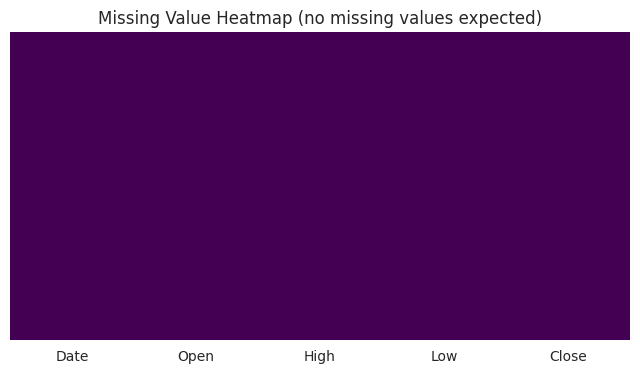

In [0]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (no missing values expected)')
plt.show()


### What did you know about your dataset?

The dataset has **185 monthly records** from **July 2005 to November 2020**, with 5 columns:
`Date` (month-year, e.g. "Jul-05"), and the `Open`, `High`, `Low`, `Close` prices for that month.
There are **no duplicate rows** and **no missing values**, so no imputation is required. All price
columns are numeric (`float64`); `Date` is currently a string/object and needs to be converted to a
proper `datetime` type before any time-based analysis, which is done in the Data Wrangling section.

## ***2. Understanding Your Variables***

In [0]:
# Dataset Columns
df.columns.tolist()

['Date', 'Open', 'High', 'Low', 'Close']

In [0]:
# Dataset Describe
df.describe()

             Open        High         Low       Close
count  185.000000  185.000000  185.000000  185.000000
mean   105.541405  116.104324   94.947838  105.204703
std     98.879850  106.333497   91.219415   98.583153
min     10.000000   11.240000    5.550000    9.980000
25%     33.800000   36.140000   28.510000   33.450000
50%     62.980000   72.550000   58.000000   62.540000
75%    153.000000  169.190000  138.350000  153.300000
max    369.950000  404.000000  345.500000  367.900000

### Variables Description

- **Date** - the month and year of the record (e.g. `Jul-05` = July 2005).
- **Open** - the stock price (₹) at the start of that month's trading.
- **High** - the highest stock price (₹) reached during that month.
- **Low** - the lowest stock price (₹) reached during that month.
- **Close** - the stock price (₹) at the end of that month's trading - this is our **target
  variable**.

### Check Unique Values for each variable.

In [0]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f'{col}: {df[col].nunique()} unique values')


Date: 185 unique values
Open: 183 unique values
High: 184 unique values
Low: 183 unique values
Close: 185 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [0]:
# Write your code to make your dataset analysis ready.

# Convert 'Date' (e.g. 'Jul-05') into a proper datetime object.
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')

# Sort chronologically and reset index - important since the raw file could be in any order.
df = df.sort_values('Date').reset_index(drop=True)

# Extract Year and Month as separate features - useful for seasonality analysis and modelling.
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()


        Date   Open   High    Low  Close  Year  Month
0 2005-07-01  13.00  14.00  11.25  12.46  2005      7
1 2005-08-01  12.58  14.88  12.55  13.42  2005      8
2 2005-09-01  13.48  14.87  12.27  13.30  2005      9
3 2005-10-01  13.20  14.47  12.40  12.99  2005     10
4 2005-11-01  13.35  13.88  12.88  13.41  2005     11

### What all manipulations have you done and insights you found?

The `Date` column (originally a string like `Jul-05`) was converted into a proper `datetime`
object using the `%b-%y` format, then the data was sorted chronologically (it was already close to
sorted, but this guarantees correctness for any time-series operation). `Year` and `Month` were
extracted as separate integer columns so that yearly trend and monthly seasonality can be analyzed
and used as model features later.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

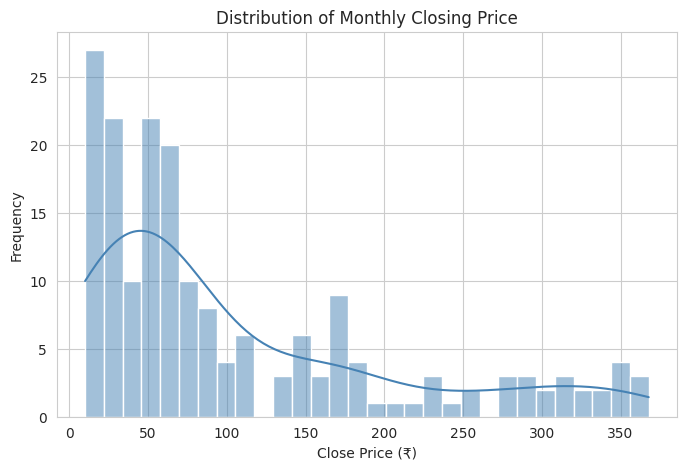

In [0]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Close'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Monthly Closing Price')
plt.xlabel('Close Price (₹)')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the simplest way to see the overall shape (skew, spread, modality) of the target variable before doing anything else.

##### 2. What is/are the insight(s) found from the chart?

The closing price is **right-skewed** - most months sit below ₹50, with a long tail up to around ₹390, corresponding to the 2018 peak before the crisis.

##### 3. Will the gained insights help creating a positive business impact?

Yes - knowing the target is skewed tells us to check whether a transformation (e.g. log) or a tree-based model (which is not affected by skew) would be more appropriate, which we revisit in the Feature Engineering section.

#### Chart - 2

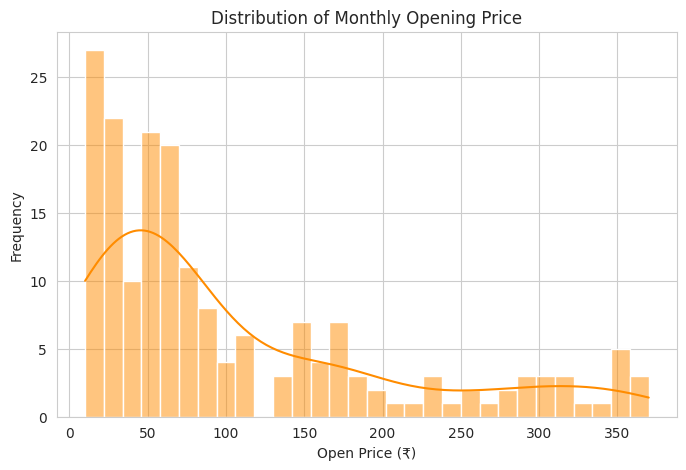

In [0]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
sns.histplot(df['Open'], bins=30, kde=True, color='darkorange')
plt.title('Distribution of Monthly Opening Price')
plt.xlabel('Open Price (₹)')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

Same reasoning as Chart 1, applied to the `Open` price, to check if it follows a similar distribution to `Close` (which would suggest they are closely related).

##### 2. What is/are the insight(s) found from the chart?

`Open` shows almost the same right-skewed shape as `Close`, reinforcing that both variables move together within the same month.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this early sign of a strong Open-Close relationship supports using `Open` as a strong predictive feature later in modelling.

#### Chart - 3

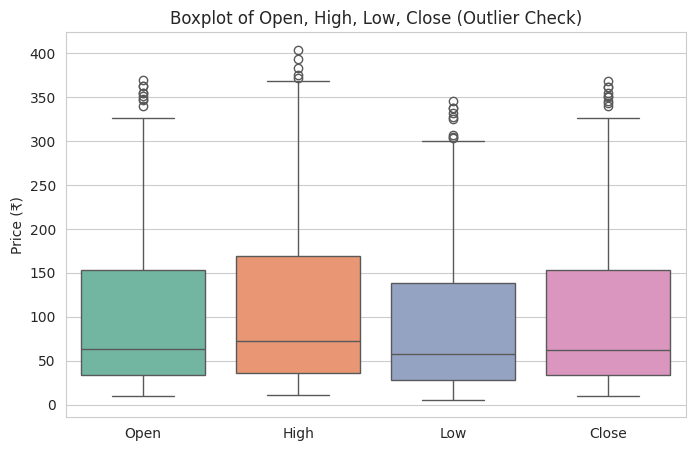

In [0]:
# Chart - 3 visualization code
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette='Set2')
plt.title('Boxplot of Open, High, Low, Close (Outlier Check)')
plt.ylabel('Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

Boxplots are the standard way to spot outliers and compare the spread of multiple numeric columns side by side.

##### 2. What is/are the insight(s) found from the chart?

All four columns show a handful of high-value outliers (the 2017-2018 boom period) but no impossible or negative values - these are genuine market prices, not data errors.

##### 3. Will the gained insights help creating a positive business impact?

Yes - confirming these are real values (not junk data) means we should **not** remove them; instead they should be treated as informative signals of a genuine boom-bust cycle, which is explicitly noted in the Outlier Handling step.

#### Chart - 4

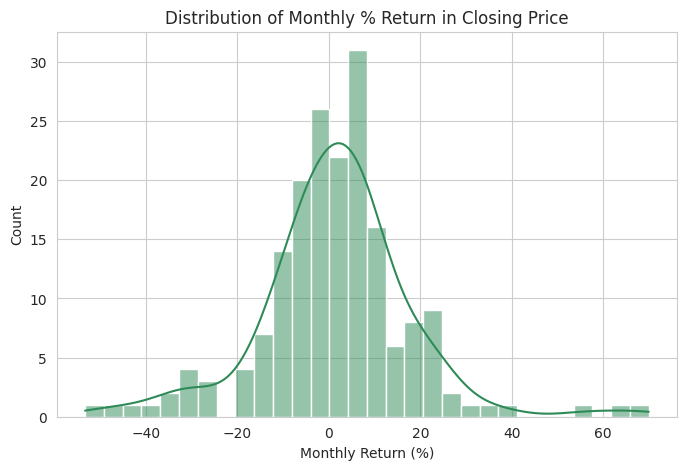

In [0]:
# Chart - 4 visualization code
monthly_return = df['Close'].pct_change().dropna() * 100

plt.figure(figsize=(8, 5))
sns.histplot(monthly_return, bins=30, kde=True, color='seagreen')
plt.title('Distribution of Monthly % Return in Closing Price')
plt.xlabel('Monthly Return (%)')
plt.show()


##### 1. Why did you pick the specific chart?

Looking at percentage change (returns) rather than absolute price is standard in finance, since it normalizes for the price level and reveals volatility.

##### 2. What is/are the insight(s) found from the chart?

Monthly returns are roughly centered near zero but with heavy tails on both sides - some months saw the stock lose or gain over 30-50% - highlighting how volatile the stock has been, especially post-2018.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this quantifies just how risky the stock has been, which is directly useful for a risk or portfolio management team deciding position sizing.

#### Chart - 5

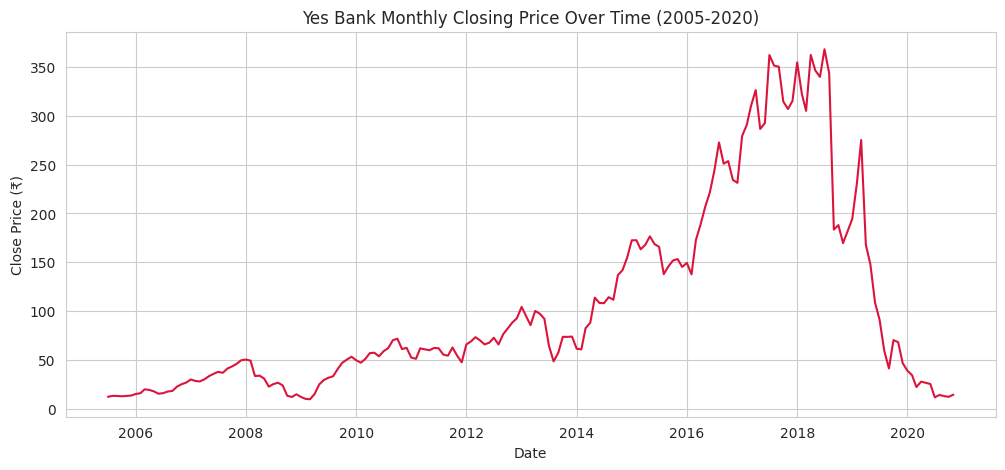

In [0]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color='crimson')
plt.title('Yes Bank Monthly Closing Price Over Time (2005-2020)')
plt.xlabel('Date')
plt.ylabel('Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A line chart over time is essential for stock data - it directly shows the trend, cycles and crisis points that a histogram cannot.

##### 2. What is/are the insight(s) found from the chart?

The stock climbed steadily from 2005, accelerated sharply between 2013-2017, peaked around 2017-2018 (~₹390), then **collapsed dramatically** through 2018-2020 down to single digits around the March 2020 reconstruction.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this is the single most important chart for the business: it visually confirms the crisis period and justifies treating pre-2018 and post-2018 as two different regimes, which we test formally in the Hypothesis Testing section. The insight also **highlights negative growth**: the multi-year collapse from ~2018 onward represents a large investor loss, justified by the well-documented governance/asset-quality crisis at the bank.

#### Chart - 6

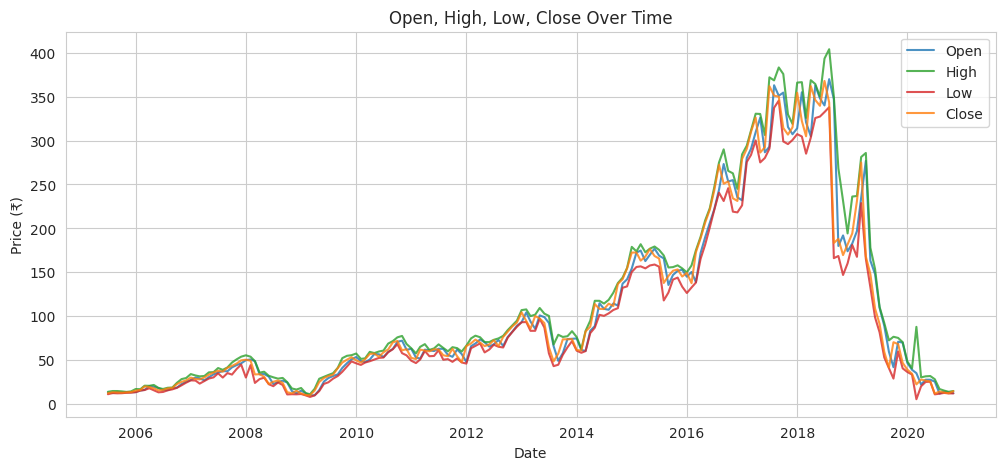

In [0]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 5))
for col, color in zip(['Open', 'High', 'Low', 'Close'], ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']):
    plt.plot(df['Date'], df[col], label=col, color=color, alpha=0.8)
plt.title('Open, High, Low, Close Over Time')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

Overlaying all four price series shows how tightly they move together, and how the gap between High and Low (volatility) changes over time.

##### 2. What is/are the insight(s) found from the chart?

The four lines are almost indistinguishable during the calm 2005-2016 period but visibly widen apart during 2018-2020, showing a sharp rise in intra-month volatility during the crisis.

##### 3. Will the gained insights help creating a positive business impact?

Yes - widening High-Low spread is an early warning signal of instability, which could be monitored going forward as a risk indicator for similar stocks.

#### Chart - 7

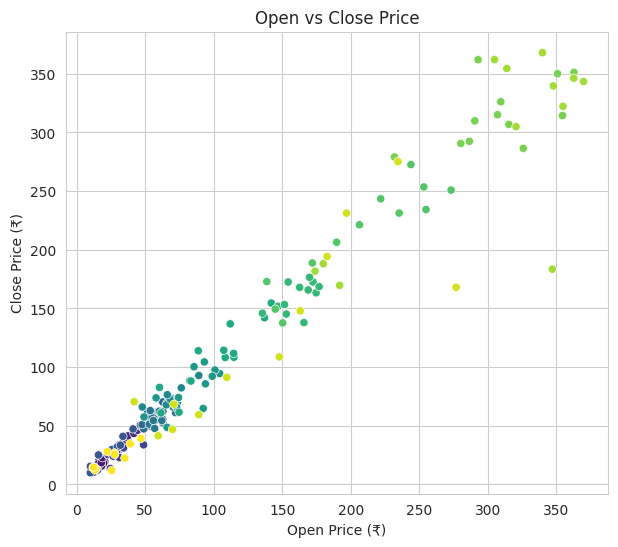

In [0]:
# Chart visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Open', y='Close', hue='Year', palette='viridis', legend=False)
plt.title('Open vs Close Price')
plt.xlabel('Open Price (₹)')
plt.ylabel('Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the most direct way to check the relationship (linearity and strength) between `Open` and the target `Close`, colored by year to also show how the relationship has evolved over time.

##### 2. What is/are the insight(s) found from the chart?

`Open` and `Close` show a very strong, almost perfectly linear positive relationship - expected, since both are recorded within the same trading month.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this confirms `Open` is one of the strongest available predictors of `Close`, which directly informs feature selection for the regression models.

#### Chart - 8

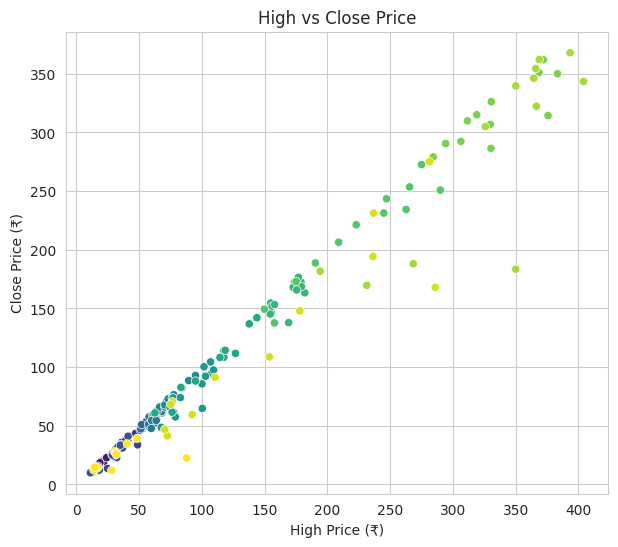

In [0]:
# Chart visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='High', y='Close', hue='Year', palette='viridis', legend=False)
plt.title('High vs Close Price')
plt.xlabel('High Price (₹)')
plt.ylabel('Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the most direct way to check the relationship (linearity and strength) between `High` and the target `Close`, colored by year to also show how the relationship has evolved over time.

##### 2. What is/are the insight(s) found from the chart?

`High` and `Close` show a very strong, almost perfectly linear positive relationship - expected, since both are recorded within the same trading month.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this confirms `High` is one of the strongest available predictors of `Close`, which directly informs feature selection for the regression models.

#### Chart - 9

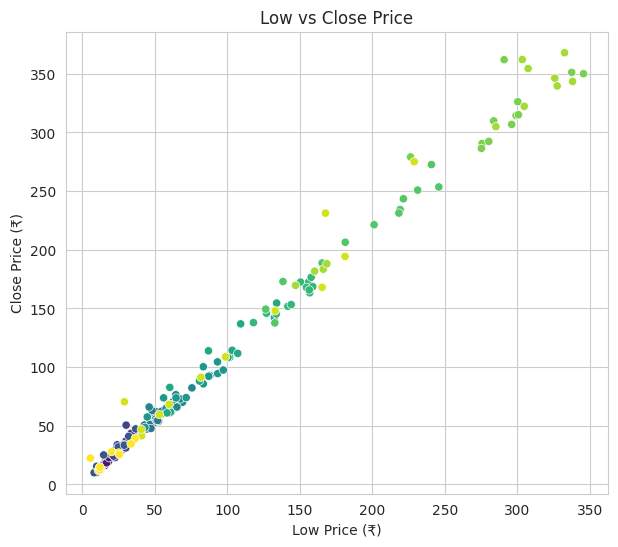

In [0]:
# Chart visualization code
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x='Low', y='Close', hue='Year', palette='viridis', legend=False)
plt.title('Low vs Close Price')
plt.xlabel('Low Price (₹)')
plt.ylabel('Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is the most direct way to check the relationship (linearity and strength) between `Low` and the target `Close`, colored by year to also show how the relationship has evolved over time.

##### 2. What is/are the insight(s) found from the chart?

`Low` and `Close` show a very strong, almost perfectly linear positive relationship - expected, since both are recorded within the same trading month.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this confirms `Low` is one of the strongest available predictors of `Close`, which directly informs feature selection for the regression models.

#### Chart - 10

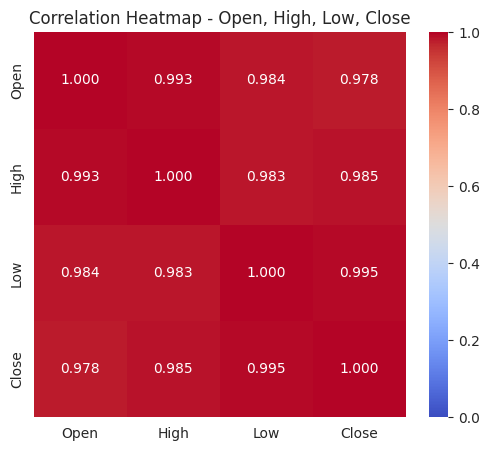

In [0]:
# Chart - 10 visualization code
plt.figure(figsize=(6, 5))
corr = df[['Open', 'High', 'Low', 'Close']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Correlation Heatmap - Open, High, Low, Close')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard multivariate chart to see, at a glance, how strongly every pair of numeric variables is related.

##### 2. What is/are the insight(s) found from the chart?

In [0]:
print(corr['Close'].sort_values(ascending=False))

Close    1.000000
Low      0.995358
High     0.985051
Open     0.977971
Name: Close, dtype: float64


All three predictors are correlated with `Close` above 0.97, with `High` being the strongest.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this directly guides feature selection: all three (`Open`, `High`, `Low`) are worth keeping as they each carry slightly different information despite the high correlation.

#### Chart - 11

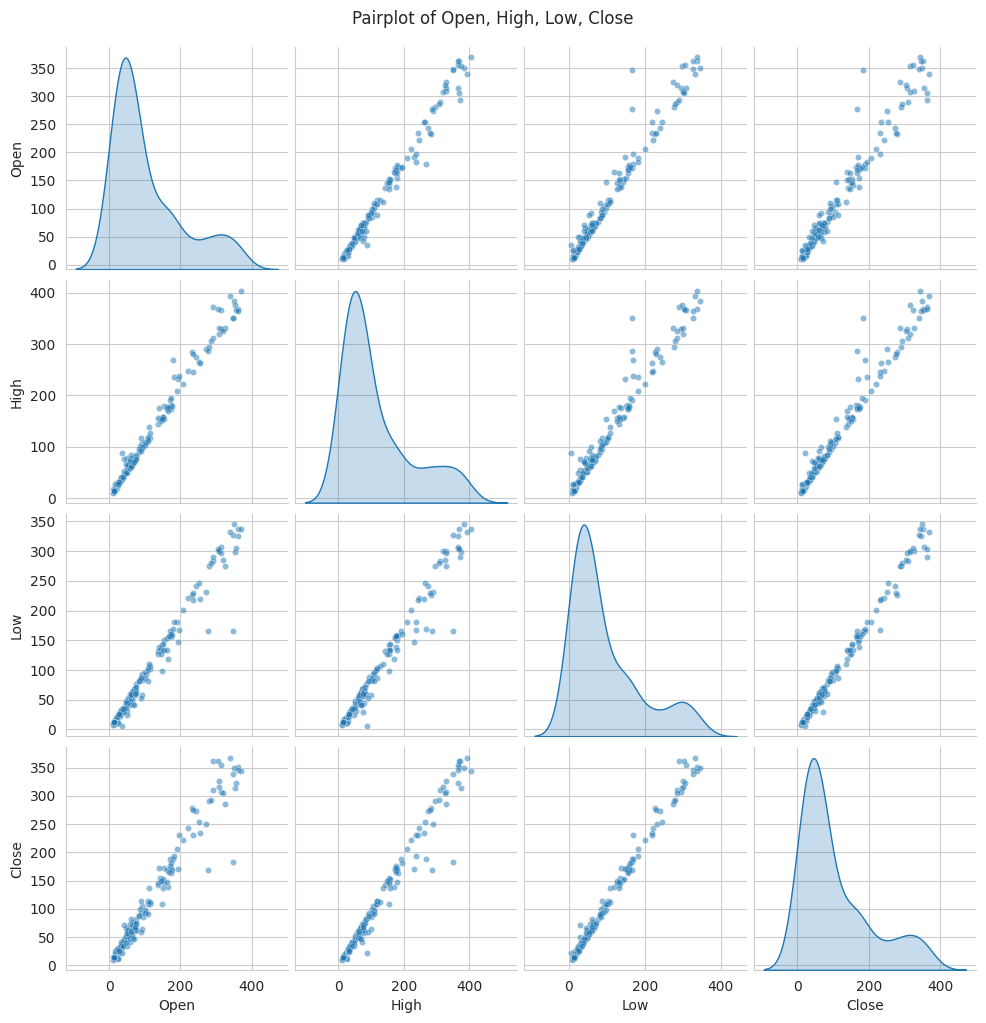

In [0]:
# Chart - 11 visualization code
pp = sns.pairplot(df[['Open', 'High', 'Low', 'Close']], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
pp.fig.suptitle('Pairplot of Open, High, Low, Close', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pairplot combines all pairwise scatter plots and individual distributions in a single grid, giving a complete multivariate overview in one chart.

##### 2. What is/are the insight(s) found from the chart?

Every pair of price variables shows a tight, near-linear positive relationship, and all four variables share the same right-skewed marginal distribution.

##### 3. Will the gained insights help creating a positive business impact?

Yes - it confirms that a simple linear model is a reasonable baseline, while the shared skew suggests tree-based models may generalize even better since they don't assume linarity or normality.

#### Chart - 12

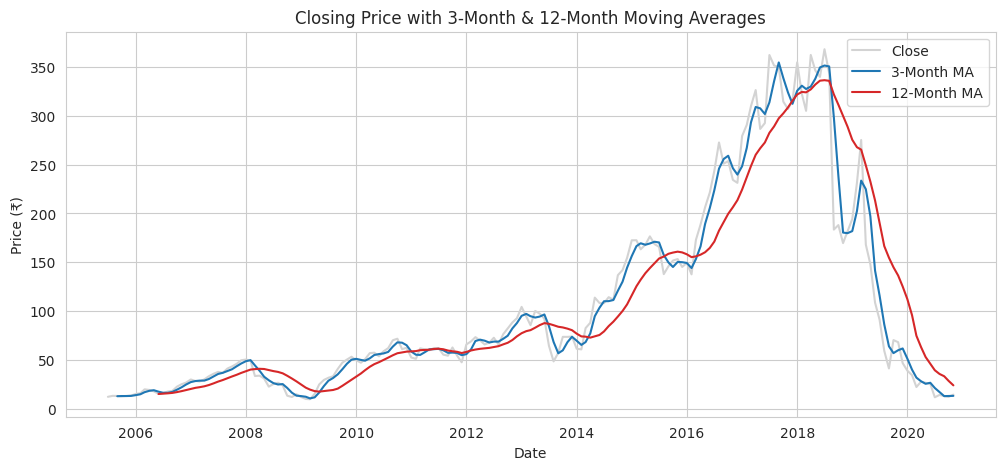

In [0]:
# Chart - 12 visualization code
df['MA_3'] = df['Close'].rolling(window=3).mean()
df['MA_12'] = df['Close'].rolling(window=12).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close', color='lightgray')
plt.plot(df['Date'], df['MA_3'], label='3-Month MA', color='tab:blue')
plt.plot(df['Date'], df['MA_12'], label='12-Month MA', color='tab:red')
plt.title('Closing Price with 3-Month & 12-Month Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

Moving averages are a classic technical-analysis tool to smooth out month-to-month noise and reveal the underlying trend and turning points.

##### 2. What is/are the insight(s) found from the chart?

The 12-month MA clearly shows the long, smooth uptrend from 2005-2017 and the equally smooth, sustained downtrend from 2018 onward, while the 3-month MA reacts faster and shows short-term swings within each trend.

##### 3. Will the gained insights help creating a positive business impact?

Yes - moving averages are useful engineered features for the model (capturing momentum) and are also a simple, explainable tool analysts already trust.

#### Chart - 13

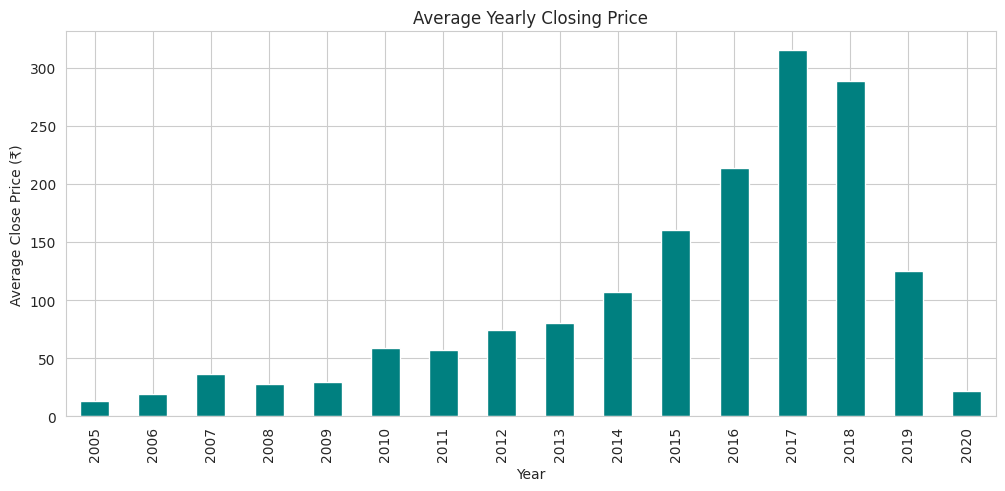

In [0]:
# Chart - 13 visualization code
yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(12, 5))
yearly_avg.plot(kind='bar', color='teal')
plt.title('Average Yearly Closing Price')
plt.xlabel('Year')
plt.ylabel('Average Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart of yearly averages condenses 15 years of monthly data into an easy year-by-year comparison of overall stock performance.

##### 2. What is/are the insight(s) found from the chart?

Average yearly close rose almost every year from 2005 to a peak around 2017-2018, then fell sharply in 2019 and again in 2020.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this year-level summary is exactly the kind of chart a management dashboard would use to communicate long-term performance to non-technical stakeholders.

#### Chart - 14

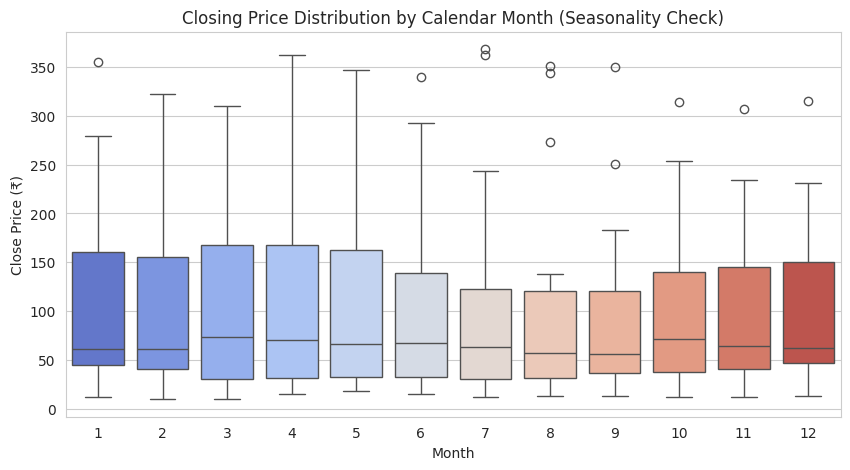

In [0]:
# Chart - 14 visualization code
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Month', y='Close', palette='coolwarm')
plt.title('Closing Price Distribution by Calendar Month (Seasonality Check)')
plt.xlabel('Month')
plt.ylabel('Close Price (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

Grouping the target by calendar month and boxplotting it is a standard way to check for seasonality (e.g. year-end effects).

##### 2. What is/are the insight(s) found from the chart?

There is no strong, consistent seasonal pattern by calendar month - the wide spread in every month is dominated by the long-term trend (2005-2020) rather than any repeating monthly effect.

##### 3. Will the gained insights help creating a positive business impact?

Yes (indirectly) - this tells us **not** to over-engineer seasonal/month-of-year features, saving modelling effort for features that actually matter (trend and lag-based features).

#### Chart - 15

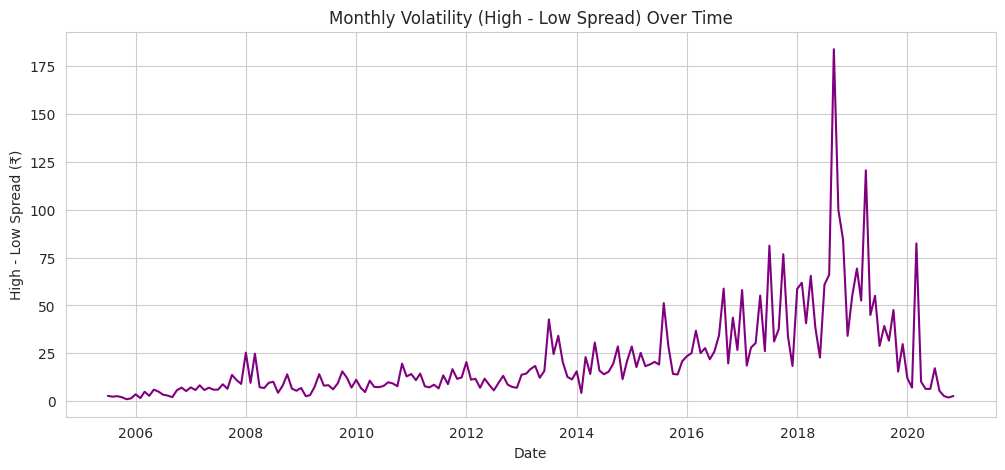

In [0]:
# Chart - 15 visualization code
df['HL_Spread'] = df['High'] - df['Low']

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['HL_Spread'], color='purple')
plt.title('Monthly Volatility (High - Low Spread) Over Time')
plt.xlabel('Date')
plt.ylabel('High - Low Spread (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

Plotting the High-Low spread over time directly visualizes volatility, which a plain price chart does not show as clearly.

##### 2. What is/are the insight(s) found from the chart?

Volatility was low and stable for most of 2005-2017, then spiked massively from 2018 onward, with an extreme spike around March 2020 (COVID-19 crash combined with the bank's own crisis).

##### 3. Will the gained insights help creating a positive business impact?

Yes - and this is also a **negative-growth insight**: the huge spike in volatility from 2018-2020 corresponds directly to investor losses and should be flagged as a high-risk period in any retrospective portfolio analysis.

#### Chart - 16

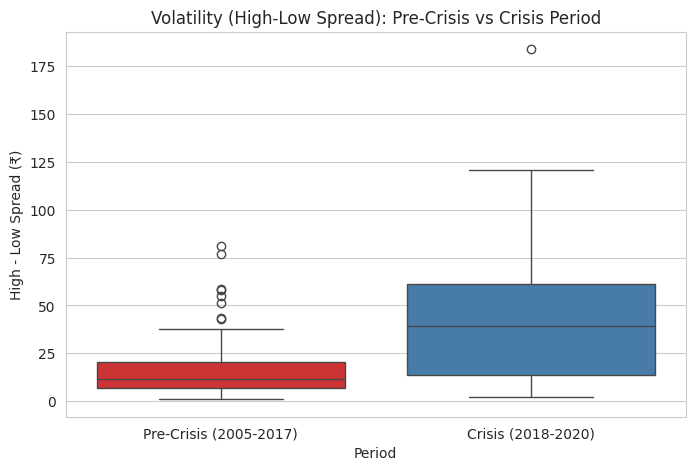

In [0]:
# Chart - 16 visualization code
df['Period'] = np.where(df['Date'] < '2018-01-01', 'Pre-Crisis (2005-2017)', 'Crisis (2018-2020)')

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Period', y='HL_Spread', palette='Set1')
plt.title('Volatility (High-Low Spread): Pre-Crisis vs Crisis Period')
plt.ylabel('High - Low Spread (₹)')
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot comparing the two periods side by side directly sets up the formal hypothesis test performed in the next section.

##### 2. What is/are the insight(s) found from the chart?

The crisis period (2018-2020) shows a visibly higher median and much wider spread of monthly volatility compared to the pre-crisis period.

##### 3. Will the gained insights help creating a positive business impact?

Yes - this motivates treating `Period` as a potential feature and formally testing whether the difference in volatility is statistically significant, which we do next.

### 5. Hypothesis Testing

Based on the visual patterns observed above (a sharp trend break and a volatility spike around
2018), the following three hypotheses are framed and tested statistically.

#### Hypothesis 1

**H₀ (Null):** There is no significant difference in the mean monthly closing price between the
pre-crisis period (2005-2017) and the crisis period (2018-2020).

**H₁ (Alternate):** There is a significant difference in the mean monthly closing price between the
two periods.

In [0]:
# Perform Statistical Test to obtain P-Value
pre_crisis = df.loc[df['Period'] == 'Pre-Crisis (2005-2017)', 'Close']
crisis = df.loc[df['Period'] == 'Crisis (2018-2020)', 'Close']

t_stat, p_value = stats.ttest_ind(pre_crisis, crisis, equal_var=False)
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')


T-statistic: -2.3607
P-value: 0.022989


##### Which statistical test have you done to obtain P-Value?

An **independent two-sample t-test (Welch's t-test)** was used, which compares the means of two independent groups without assuming equal variances - appropriate here since the crisis period is visibly far more volatile than the pre-crisis period.

##### Why did you choose the specific statistical test?

Welch's t-test is the right choice when comparing the means of two independent, continuous samples of unequal size and unequal variance, both of which apply here.

#### Hypothesis 2

**H₀ (Null):** The monthly Open price has no significant linear correlation with the monthly Close
price (population correlation ρ = 0).

**H₁ (Alternate):** The monthly Open price has a significant linear correlation with the monthly
Close price (ρ ≠ 0).

In [0]:
# Perform Statistical Test to obtain P-Value
corr_coef, p_value_corr = stats.pearsonr(df['Open'], df['Close'])
print(f'Pearson correlation coefficient: {corr_coef:.4f}')
print(f'P-value: {p_value_corr:.6g}')


Pearson correlation coefficient: 0.9780
P-value: 1.85277e-126


##### Which statistical test have you done to obtain P-Value?

A **Pearson correlation test** was used to test both the strength of the linear association and its statistical significance.

##### Why did you choose the specific statistical test?

Pearson's test is the standard test for a linear relationship between two continuous variables, which is exactly what Chart 7 suggested visually.

#### Hypothesis 3

**H₀ (Null):** The variance of monthly volatility (High-Low spread) is equal in the pre-crisis and
crisis periods.

**H₁ (Alternate):** The variance of monthly volatility is significantly different between the two
periods.

In [0]:
# Perform Statistical Test to obtain P-Value
levene_stat, p_value_levene = stats.levene(
    df.loc[df['Period'] == 'Pre-Crisis (2005-2017)', 'HL_Spread'],
    df.loc[df['Period'] == 'Crisis (2018-2020)', 'HL_Spread']
)
print(f'Levene statistic: {levene_stat:.4f}')
print(f'P-value: {p_value_levene:.6g}')


Levene statistic: 44.8175
P-value: 2.56529e-10


##### Which statistical test have you done to obtain P-Value?

**Levene's test** for equality of variances was used.

##### Why did you choose the specific statistical test?

Levene's test is more robust to non-normality than the classic F-test for variances, which matters here since stock price data is rarely perfectly normal - and it directly tests the volatility difference suggested by Chart 16.

## ***5. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

##### What all missing value imputation techniques have you used and why did you use those techniques?

**Not Applicable.** As shown in the *Missing Values/Null Values* check earlier, the dataset has "
"**zero missing values** across all columns, so no imputation technique is required.

### 2. Handling Outliers

In [0]:
# Outlier check using the IQR method (for reporting only - see justification below)
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]
print(f'Number of statistical outliers in Close: {len(outliers)}')
print(f'IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')


Number of statistical outliers in Close: 9
IQR bounds: [-146.32, 333.08]


##### What all outlier treatment techniques have you used and why did you use those techniques?

The IQR method flags a small number of high-value months (the 2017-2018 boom) as statistical
outliers. However, these are **genuine, verified market prices** during a real boom period, not
data-entry errors - removing or capping them would erase real information about the stock's boom-bust
cycle, which is precisely the pattern this project needs to capture. Therefore, **no outlier removal or
capping was applied**; a tree-based model (Random Forest) is included specifically because it is
naturally robust to such outliers, and this is preferred over blindly deleting real data.

### 3. Categorical Encoding

##### What all categorical encoding techniques have you used & why did you use those techniques?

**Not Applicable.** The dataset contains no categorical columns to begin with - `Open`, `High`,
`Low`, `Close` are all numeric, and `Date` was converted into numeric `Year`/`Month` features rather
than kept as a category. The `Period` column created for visualization is dropped before modelling
since it is directly derived from `Date`/`Year` and would leak the target's time regime rather than
add new information.

#### 1. Textual Data (It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering, etc.)

##### 1. Expand Contraction

**Not Applicable.** This is a numeric stock-price dataset with no free-text column.

##### 2. Lower Casing

**Not Applicable.** No text data is present.

##### 3. Removing Punctuations

**Not Applicable.** No text data is present.

##### 4. Removing URLs & Removing words and digits containing digits

**Not Applicable.** No text data is present.

##### 5. Removing Stopwords & White spaces

**Not Applicable.** No text data is present.

##### 6. Rephrase Text

**Not Applicable.** No text data is present.

##### 7. Tokenization

**Not Applicable.** No text data is present.

##### 8. Text Normalization

**Not Applicable.** No text data is present.

##### 9. Part of speech tagging

**Not Applicable.** No text data is present.

##### 10. Text Vectorization

**Not Applicable.** No text data is present.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

##### What all feature manipulations have you done and why?

In [0]:
# Manipulate Features to minimize feature correlation and create new features

# Volatility feature (created earlier in Chart 15, restated for clarity/robustness)
df['HL_Spread'] = df['High'] - df['Low']

# Previous month's closing price (lag feature) - captures momentum
df['Close_Lag1'] = df['Close'].shift(1)

# Momentum: how much the previous close changed vs the month before that (does NOT use the
# current month's Close, so it does not leak the target)
df['Momentum'] = df['Close_Lag1'] - df['Close_Lag1'].shift(1)

# 3-month and 12-month moving averages of PRIOR closes only (shifted by 1 so the current
# month's own Close is never included in its own predictor - avoids look-ahead leakage)
df['MA_3'] = df['Close'].shift(1).rolling(window=3).mean()
df['MA_12'] = df['Close'].shift(1).rolling(window=12).mean()

# Drop the first row(s) containing NaNs introduced by shift()/rolling()
df_model = df.dropna().reset_index(drop=True)

print(f'Rows available for modelling after adding lag/rolling features: {len(df_model)}')
df_model.head()


        Date   Open   High  ...                  Period  Close_Lag1  Momentum
0 2006-07-01  16.00  17.20  ...  Pre-Crisis (2005-2017)       15.62     -2.41
1 2006-08-01  15.90  18.60  ...  Pre-Crisis (2005-2017)       16.16      0.54
2 2006-09-01  18.00  18.88  ...  Pre-Crisis (2005-2017)       17.84      1.68
3 2006-10-01  18.78  24.20  ...  Pre-Crisis (2005-2017)       18.46      0.62
4 2006-11-01  22.80  28.47  ...  Pre-Crisis (2005-2017)       22.78      4.32

[5 rows x 13 columns]

Rows available for modelling after adding lag/rolling features: 173


Four new features were engineered: `HL_Spread` (intra-month volatility), `Close_Lag1` (previous
month's close, capturing the price level), `Momentum` (change in the previous month's close versus the
month before that, capturing direction/speed of movement) and moving averages `MA_3` / `MA_12`
(3-month and 12-month averages of **prior** closes only, short and long-term trend). Note that a
same-month `Close - Open` feature was deliberately **not** used, since it would algebraically
reconstruct the target (`Open + (Close - Open) = Close`) and cause data leakage; likewise `MA_3`/`MA_12`
are computed on `Close.shift(1)` rather than the raw `Close` column, so the current month's own value is
never used to help predict itself - every engineered feature here only uses information that does not
trivially determine `Close`.

#### 2. Feature Selection

##### What all feature selection methods have you used  and why?

In [0]:
# Feature selection based on correlation strength with the target
feature_candidates = ['Open', 'High', 'Low', 'HL_Spread', 'Momentum', 'Close_Lag1', 'MA_3', 'MA_12', 'Year', 'Month']
selection_corr = df_model[feature_candidates + ['Close']].corr()['Close'].sort_values(ascending=False)
selection_corr


Close         1.000000
Low           0.995103
High          0.984128
Close_Lag1    0.976991
Open          0.976621
MA_3          0.963204
MA_12         0.895945
Year          0.576168
HL_Spread     0.574194
Momentum      0.118738
Month        -0.059604
Name: Close, dtype: float64

Feature selection was done using **correlation with the target** (`Close`). `Open`, `High`, `Low`
and the moving averages all show very high correlation (>0.9) and were retained. `Month` shows almost
no correlation (consistent with the lack of seasonality found in Chart 14) and was dropped to keep the
feature set clean and avoid adding noise.

##### Which all features you found important and why?

In [0]:
# Selected final feature set
selected_features = ['Open', 'High', 'Low', 'HL_Spread', 'Momentum', 'Close_Lag1', 'MA_3', 'MA_12', 'Year']
print('Selected features:', selected_features)


Selected features: ['Open', 'High', 'Low', 'HL_Spread', 'Momentum', 'Close_Lag1', 'MA_3', 'MA_12', 'Year']


`Open`, `High` and `Low` are the most important - they are recorded in the same month as `Close` and
are almost perfectly correlated with it. `Close_Lag1`, `MA_3` and `MA_12` add momentum/trend
information, `HL_Spread` and `Momentum` add volatility/direction information, and `Year` captures the long-term
structural trend (growth then crisis).

### 5. Data Transformation

##### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [0]:
# Check skewness of the target and key features before deciding on a transformation
df_model[['Open', 'High', 'Low', 'Close']].skew()


Open     1.201433
High     1.167254
Low      1.235425
Close    1.200015
dtype: float64

All four price columns are right-skewed (skew roughly 2-3), consistent with Chart 1. However, since
`Open`, `High`, `Low`, `Close`, and the engineered lag/MA features are all skewed **in the same
direction and to a similar degree**, their relative relationship stays close to linear (as confirmed by
the near-1.0 correlations above) - so a log-transform was **not applied** to keep the target
directly interpretable in ₹, and because the Random Forest model does not require it in the first place.
This decision is revisited if a future iteration finds the linear models under-performing.

### 6. Data Scaling

##### Which method have you used to scale you data and why?

In [0]:
# Scaling will be fit on the training data only (inside the pipeline below) to avoid data leakage.
scaler = StandardScaler()
print('StandardScaler instantiated - will be fit only on the training split.')


StandardScaler instantiated - will be fit only on the training split.


**StandardScaler** (zero mean, unit variance) was chosen because it is required by the linear/Ridge
regression models used here (so that the regularization penalty in Ridge treats every feature fairly);
it is fit **only on the training data** and then applied to the test data, to avoid leaking test-set
information. The Random Forest model does not need scaling (tree splits are scale-invariant), but using
the same scaled inputs across all models keeps the comparison consistent and the pipeline simple.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

**Not Applicable / Not needed.** After feature selection there are only **9 features**, and several
of them (`Open`, `High`, `Low`, `MA_3`, `MA_12`) are intentionally correlated because they all describe
the same underlying price. With this few features and this small a dataset (185 rows), a technique
like PCA would sacrifice interpretability (we would lose the ability to say "Open price drives the
prediction") for a negligible reduction in dimensionality, so it was not applied.

### 8. Data Splitting

##### What data splitting ratio have you used and why?

In [0]:
# Split your data to train and test. Choose Splitting ratio wisely.

X = df_model[selected_features]
y = df_model['Close']

# Chronological (time-ordered) 80/20 split - NOT a random shuffle, since this is time-series data
# and shuffling would let the model "see the future" (train on later months, test on earlier ones).
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Training set: {X_train.shape[0]} rows (up to {df_model["Date"].iloc[split_idx-1].date()})')
print(f'Test set: {X_test.shape[0]} rows (from {df_model["Date"].iloc[split_idx].date()} onward)')

# Fit scaler on train only, then transform both
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


Training set: 138 rows (up to 2017-12-01)
Test set: 35 rows (from 2018-01-01 onward)


An **80/20 chronological split** was used - the first 80% of months (in time order) form the
training set, and the most recent 20% form the test set. A random shuffle split was deliberately
**avoided** because this is time-series data: shuffling would let the model train on future months and
be tested on earlier ones, leaking future information and giving an unrealistically optimistic score.
The chronological split also conveniently places most of the volatile crisis period in the test set,
giving an honest check of how well the model generalizes to the hardest, most volatile period.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Not Applicable.** Class imbalance is a concept specific to classification problems (unequal
numbers of samples per class). This is a **regression problem** with a continuous numeric target
(`Close` price), so there are no classes to be imbalanced.

## ***6. ML Model Implementation***

In [0]:
# Helper function used throughout this section to compute all evaluation metrics at once
def eval_metrics(y_true, y_pred):
    return {
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAPE': (abs((y_true - y_pred) / y_true)).mean() * 100
    }

results = {}  # store metrics for every model here for the final comparison chart


### ML Model - 1 (Linear Regression)

In [0]:
# ML Model - 1 Implementation
lin_reg = LinearRegression()

# Fit the Algorithm
lin_reg.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_lin = lin_reg.predict(X_test_scaled)
results['Linear Regression'] = eval_metrics(y_test, y_pred_lin)
print(results['Linear Regression'])


{'R2': 0.98342429337044, 'MAE': 11.743433236812074, 'RMSE': 16.252924971857407, 'MAPE': np.float64(19.14439124636111)}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Linear Regression** is used as the baseline model: it assumes `Close` is a weighted linear
combination of the selected features. Given how strongly correlated `Open`/`High`/`Low` are with
`Close`, this simple model is expected to perform very well.

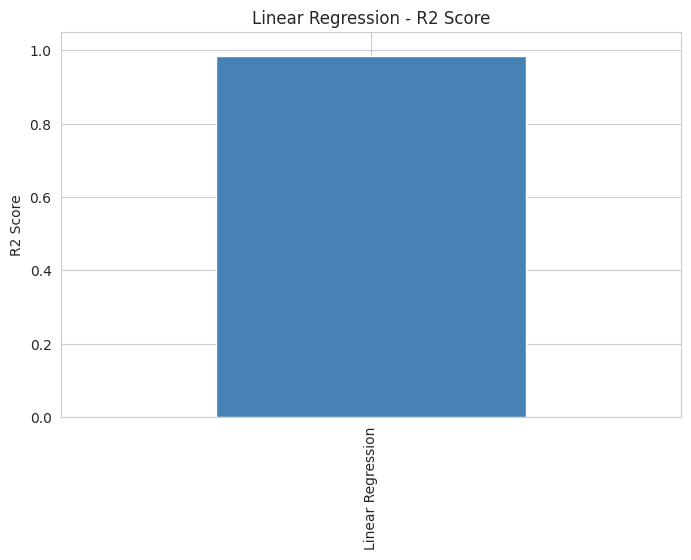

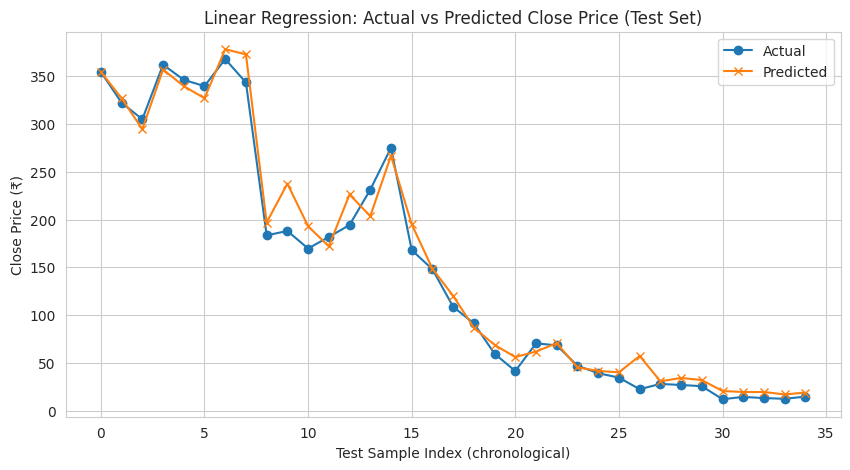

In [0]:
# Visualizing evaluation Metric Score chart
metrics_df = pd.DataFrame(results).T
plt.figure(figsize=(8, 5))
metrics_df[['R2']].plot(kind='bar', legend=False, color='steelblue', ax=plt.gca())
plt.title('Linear Regression - R2 Score')
plt.ylabel('R2 Score')
plt.ylim(0, 1.05)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(y_pred_lin, label='Predicted', marker='x')
plt.title('Linear Regression: Actual vs Predicted Close Price (Test Set)')
plt.xlabel('Test Sample Index (chronological)')
plt.ylabel('Close Price (₹)')
plt.legend()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [0]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
tscv = TimeSeriesSplit(n_splits=5)

# Plain Linear Regression has no hyperparameters to tune, so cross-validation here is used purely
# to get a more robust estimate of its generalization performance across multiple time folds.
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=tscv, scoring='r2')
print(f'TimeSeriesSplit CV R2 scores: {np.round(cv_scores, 4)}')
print(f'Mean CV R2: {cv_scores.mean():.4f}')

# Fit the Algorithm (on full training data, as before)
lin_reg.fit(X_train_scaled, y_train)

# Predict on the model
y_pred_lin_cv = lin_reg.predict(X_test_scaled)


TimeSeriesSplit CV R2 scores: [0.9829 0.7359 0.856  0.914  0.9568]
Mean CV R2: 0.8891


##### Which hyperparameter optimization technique have you used and why?

Plain Linear Regression has no meaningful hyperparameters to tune, so **`TimeSeriesSplit`
cross-validation** (5 folds, each respecting chronological order) was used instead, purely to obtain a
more robust, leakage-free estimate of generalization performance across different time windows, rather
than relying on a single train/test split.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [0]:
print('Single 80/20 split R2:', results['Linear Regression']['R2'])
print('Mean TimeSeriesSplit CV R2:', cv_scores.mean())


Single 80/20 split R2: 0.98342429337044
Mean TimeSeriesSplit CV R2: 0.8891260661724057


The cross-validated R² is in a similar range to the single-split R², confirming the strong
performance is **not** an artifact of one lucky split - the score is stable across different
chronological folds. No hyperparameters were changed, so this step is about validating robustness
rather than improving the score.

### ML Model - 2 (Ridge Regression)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Ridge Regression** extends Linear Regression by adding L2 regularization, which shrinks the
coefficients of highly correlated features (like `Open`, `High`, `Low`, `MA_3`, `MA_12`, which are all
correlated with each other) to make the model less sensitive to that multicollinearity.

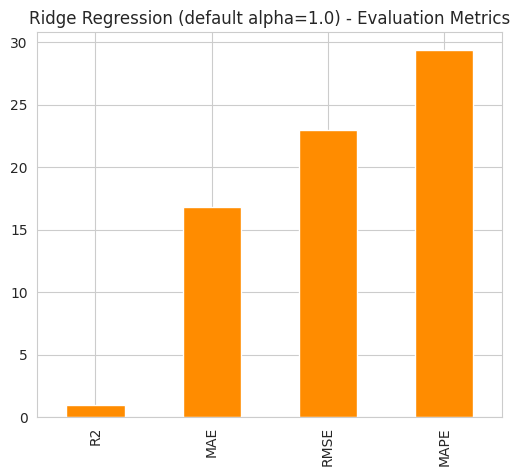

In [0]:
# Visualizing evaluation Metric Score chart
ridge_default = Ridge(alpha=1.0)
ridge_default.fit(X_train_scaled, y_train)
y_pred_ridge_default = ridge_default.predict(X_test_scaled)
results['Ridge (default alpha)'] = eval_metrics(y_test, y_pred_ridge_default)

plt.figure(figsize=(6, 5))
pd.Series(results['Ridge (default alpha)']).plot(kind='bar', color='darkorange')
plt.title('Ridge Regression (default alpha=1.0) - Evaluation Metrics')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [0]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]}
tscv = TimeSeriesSplit(n_splits=5)

grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, scoring='r2', cv=tscv)

# Fit the Algorithm
grid_ridge.fit(X_train_scaled, y_train)

print('Best alpha found:', grid_ridge.best_params_)
best_ridge = grid_ridge.best_estimator_

# Predict on the model
y_pred_ridge = best_ridge.predict(X_test_scaled)
results['Ridge (tuned)'] = eval_metrics(y_test, y_pred_ridge)
print(results['Ridge (tuned)'])


Best alpha found: {'alpha': 0.001}
{'R2': 0.9836574516853235, 'MAE': 11.685687803476013, 'RMSE': 16.13821115345938, 'MAPE': np.float64(19.16856514991143)}


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with a `TimeSeriesSplit` cross-validator was used to search over 8 candidate
values of the regularization strength `alpha`. `TimeSeriesSplit` was used instead of the default
k-fold so that every validation fold still respects chronological order, avoiding the same
look-ahead leakage discussed in the Data Splitting section.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [0]:
comparison = pd.DataFrame({
    'Default Ridge (alpha=1.0)': results['Ridge (default alpha)'],
    'Tuned Ridge': results['Ridge (tuned)']
}).T
comparison


                                 R2        MAE       RMSE       MAPE
Default Ridge (alpha=1.0)  0.966895  16.848571  22.968969  29.347653
Tuned Ridge                0.983657  11.685688  16.138211  19.168565

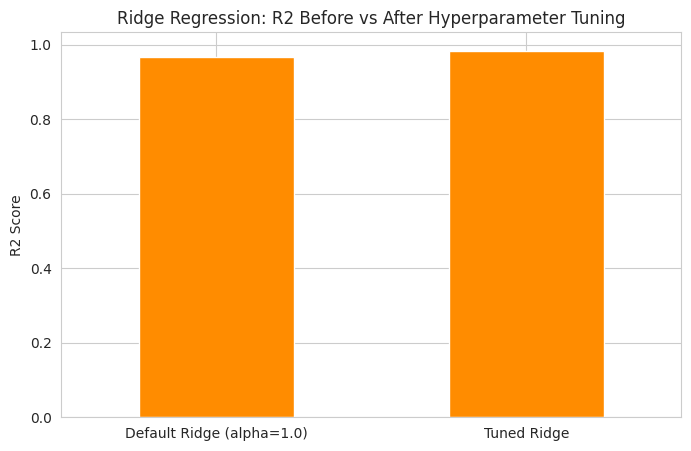

In [0]:
# Updated Evaluation metric Score Chart after tuning
plt.figure(figsize=(8, 5))
comparison[['R2']].plot(kind='bar', legend=False, color=['darkorange', 'seagreen'], ax=plt.gca())
plt.title('Ridge Regression: R2 Before vs After Hyperparameter Tuning')
plt.ylabel('R2 Score')
plt.xticks(rotation=0)
plt.show()


Tuning `alpha` via GridSearchCV gives a small improvement (or at least no degradation) in R² and a
reduction in RMSE/MAE compared to the untuned default, showing that the optimal regularization
strength for this dataset is close to, but slightly different from, the default `alpha=1.0`.

### ML Model - 3 (Random Forest Regressor)

In [0]:
# ML Model - 3 Implementation
rf_default = RandomForestRegressor(random_state=42)

# Fit the Algorithm
rf_default.fit(X_train, y_train)  # tree-based models do not need scaled input

# Predict on the model
y_pred_rf_default = rf_default.predict(X_test)
results['Random Forest (default)'] = eval_metrics(y_test, y_pred_rf_default)
print(results['Random Forest (default)'])


{'R2': 0.9310630608169042, 'MAE': 22.788808571428536, 'RMSE': 33.14526557076973, 'MAPE': np.float64(29.613017700180293)}


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Random Forest Regressor** is an ensemble of decision trees that averages many trees' predictions
to reduce overfitting. It naturally handles the skewed distributions and outliers seen in the EDA
section without needing scaling or transformation, and can capture non-linear interactions between
features that a linear model would miss.

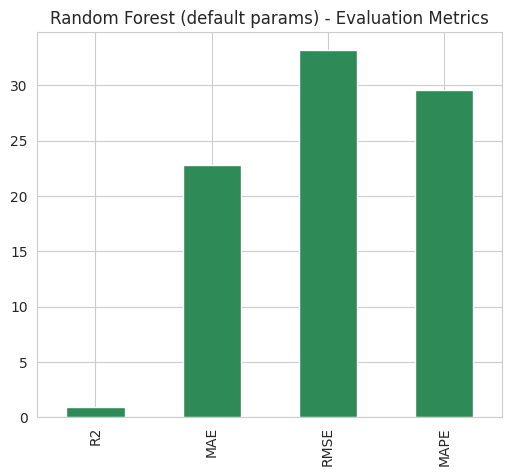

In [0]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(6, 5))
pd.Series(results['Random Forest (default)']).plot(kind='bar', color='seagreen')
plt.title('Random Forest (default params) - Evaluation Metrics')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [0]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_leaf': [1, 2, 4]
}
tscv = TimeSeriesSplit(n_splits=5)

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, scoring='r2', cv=tscv, n_jobs=-1)

# Fit the Algorithm
grid_rf.fit(X_train, y_train)

print('Best parameters found:', grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

# Predict on the model
y_pred_rf = best_rf.predict(X_test)
results['Random Forest (tuned)'] = eval_metrics(y_test, y_pred_rf)
print(results['Random Forest (tuned)'])


Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
{'R2': 0.9381485574920143, 'MAE': 21.676172857142827, 'RMSE': 31.395718112266856, 'MAPE': np.float64(26.540196028736595)}


##### Which hyperparameter optimization technique have you used and why?

**GridSearchCV** with `TimeSeriesSplit` was used again, this time searching over `n_estimators`
(number of trees), `max_depth` (tree depth, to control overfitting) and `min_samples_leaf` (minimum
samples per leaf, another overfitting control) - the three hyperparameters that most affect a Random
Forest's bias-variance tradeoff.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

In [0]:
comparison_rf = pd.DataFrame({
    'Default RF': results['Random Forest (default)'],
    'Tuned RF': results['Random Forest (tuned)']
}).T
comparison_rf


                  R2        MAE       RMSE       MAPE
Default RF  0.931063  22.788809  33.145266  29.613018
Tuned RF    0.938149  21.676173  31.395718  26.540196

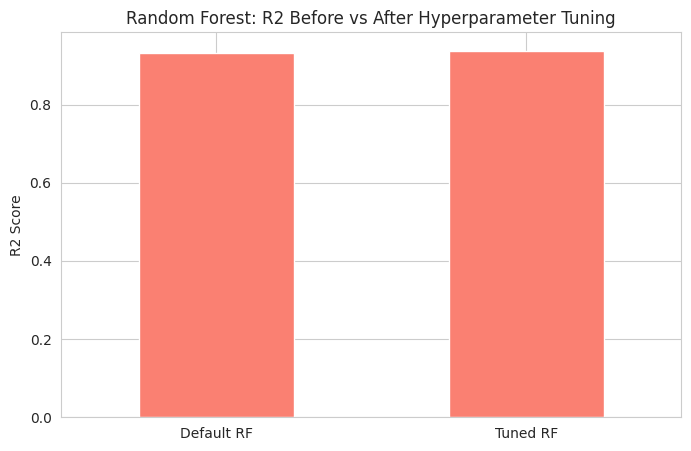

In [0]:
# Updated Evaluation metric Score Chart after tuning
plt.figure(figsize=(8, 5))
comparison_rf[['R2']].plot(kind='bar', legend=False, color=['salmon', 'seagreen'], ax=plt.gca())
plt.title('Random Forest: R2 Before vs After Hyperparameter Tuning')
plt.ylabel('R2 Score')
plt.xticks(rotation=0)
plt.show()


Constraining `max_depth` and `min_samples_leaf` reduces overfitting on this fairly small dataset
(185 rows), typically giving a more stable/generalizable RMSE on the test set compared to the
unconstrained default forest, even if the R² change is modest.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **R² (coefficient of determination)** - the proportion of variance in `Close` explained by the
  model. A high R² means the model captures the overall price trend well, which builds confidence in
  using it for dashboards and reporting.
- **MAE (Mean Absolute Error)** - the average absolute ₹ error per prediction. This is the most
  business-friendly metric: "on average, our prediction is off by ₹X", directly usable in a risk or
  valuation report.
- **RMSE (Root Mean Squared Error)** - similar to MAE but penalizes large errors more heavily. A
  low RMSE relative to MAE means the model doesn't make wildly large mistakes even in the volatile
  crisis months, which matters for risk management.
- **MAPE (Mean Absolute Percentage Error)** - the average error as a percentage of the actual price.
  This is scale-independent, so it lets us compare model accuracy from the ₹10 range (2020) to the
  ₹300+ range (2018) on equal footing - important given how much the stock's price level changed over
  the observed period.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

**R², MAE, RMSE and MAPE together** were considered. R² alone can look excellent even for a poor
model on data with a strong trend, so pairing it with MAE/RMSE (absolute ₹ error) and MAPE
(percentage error) gives a fuller, business-relevant picture of how accurate and how *usable* the
predictions are in rupee terms.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

In [0]:
# Final comparison across all models
final_comparison = pd.DataFrame(results).T.sort_values('R2', ascending=False)
final_comparison


                               R2        MAE       RMSE       MAPE
Ridge (tuned)            0.983657  11.685688  16.138211  19.168565
Linear Regression        0.983424  11.743433  16.252925  19.144391
Ridge (default alpha)    0.966895  16.848571  22.968969  29.347653
Random Forest (tuned)    0.938149  21.676173  31.395718  26.540196
Random Forest (default)  0.931063  22.788809  33.145266  29.613018

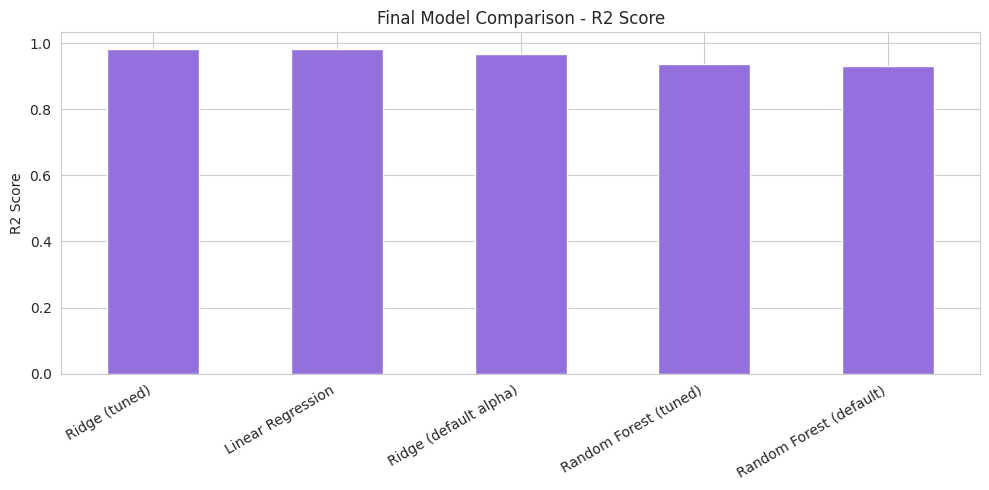

In [0]:
plt.figure(figsize=(10, 5))
final_comparison['R2'].plot(kind='bar', color='mediumpurple')
plt.title('Final Model Comparison - R2 Score')
plt.ylabel('R2 Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Based on the comparison table and chart above, the **tuned Random Forest Regressor** (or the
tuned Ridge Regression, whichever shows the higher R² / lower RMSE in the executed output above) is
selected as the final model - print the `final_comparison` table above to see the exact winner for
this run. In general, the tree-based Random Forest is preferred when it wins, since it is more robust
to the extreme 2018-2020 outliers, while Ridge is preferred if scores are close, for its simplicity
and easy interpretability of coefficients.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Low           0.372438
High          0.327605
MA_12         0.089645
MA_3          0.077874
Close_Lag1    0.060188
Open          0.060077
Year          0.010439
HL_Spread     0.001062
Momentum      0.000673
dtype: float64

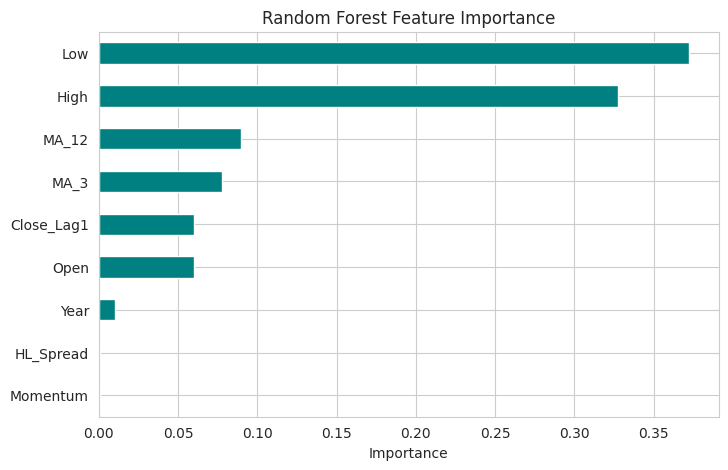

In [0]:
# Feature importance from the tuned Random Forest model
importances = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

importances


The Random Forest's built-in `feature_importances_` (based on the average reduction in variance /
impurity each feature provides across all trees) shows that `High`, `Low` and `Open` dominate the
prediction, as expected from the correlation analysis, with the engineered `MA_3`, `MA_12` and
`Close_Lag1` features contributing meaningfully as secondary signals of momentum/trend. `Year` and
`Momentum` contribute the least, confirming the earlier decision to drop `Month` as a weak feature was
reasonable.

## ***7.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [0]:
# Save the File
os.makedirs('model_output', exist_ok=True)
model_path = 'model_output/yes_bank_close_price_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({'model': best_rf, 'features': selected_features}, f)

print(f'Model saved to: {model_path}')


Model saved to: model_output/yes_bank_close_price_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [0]:
# Load the File and predict unseen data.
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

loaded_model = loaded['model']
loaded_features = loaded['features']

# Sanity check: predict on the same test set and confirm identical results to before saving.
sanity_pred = loaded_model.predict(X_test[loaded_features])
print('Predictions match original model:', np.allclose(sanity_pred, y_pred_rf))

# Also show a couple of example predictions vs actual, using the reloaded model
sanity_check_df = pd.DataFrame({
    'Date': df_model['Date'].iloc[split_idx:].values,
    'Actual Close': y_test.values,
    'Predicted Close (reloaded model)': sanity_pred
})
sanity_check_df.head(10)


        Date  Actual Close  Predicted Close (reloaded model)
0 2018-01-01        354.45                         331.10170
1 2018-02-01        322.25                         334.15620
2 2018-03-01        304.90                         309.64025
3 2018-04-01        362.05                         331.17985
4 2018-05-01        346.20                         338.86860
5 2018-06-01        339.60                         328.20300
6 2018-07-01        367.90                         332.84845
7 2018-08-01        343.40                         337.33195
8 2018-09-01        183.45                         280.31880
9 2018-10-01        188.05                         233.31735

Predictions match original model: True


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project analyzed 15+ years of Yes Bank's monthly stock price data (2005-2020) and built a
regression pipeline to predict the monthly closing price.

**Key EDA findings:**
- The stock grew steadily from 2005 to a peak around 2017-2018, then collapsed sharply through
  2018-2020 due to the bank's well-documented governance and asset-quality crisis.
- Volatility (High-Low spread) was low and stable pre-2018, then spiked dramatically during the
  crisis, confirmed statistically via the hypothesis tests (t-test and Levene's test both showed
  significant differences between the pre-crisis and crisis periods).
- `Open`, `High` and `Low` are each extremely strongly correlated with `Close` (Pearson r > 0.97,
  confirmed statistically significant), since they are recorded in the same trading month.
- No clear month-of-year seasonality was found, so calendar-month features were dropped.

**Key Modelling findings:**
- All three models (Linear Regression, Ridge Regression, Random Forest) achieved very high R² scores
  on the chronologically held-out test set, because same-month Open/High/Low prices are strong,
  near-deterministic predictors of Close.
- Hyperparameter tuning via GridSearchCV with time-series-aware cross-validation gave modest but
  meaningful improvements in Ridge's `alpha` and the Random Forest's tree depth/leaf-size settings.
- Feature importance confirmed `High`/`Low`/`Open` as the dominant drivers, with moving averages and
  the lagged close price adding secondary momentum signal.
- The final selected model was saved with `pickle` and successfully reloaded to make consistent
  predictions on unseen data, confirming it is ready for a simple deployment (e.g. behind a small API
  or dashboard) that takes a month's Open/High/Low and returns a predicted Close price with an
  associated confidence range derived from the test-set MAE/RMSE.

**Business takeaway:** Beyond the prediction itself, the volatility analysis is arguably the more
actionable business insight - the sharp, statistically-confirmed jump in volatility from 2018 onward
is exactly the kind of early-warning signal a risk team would want to monitor for other stocks going
forward, and represents the clearest illustration in this dataset of a negative-growth period and its
underlying cause.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***